# **A notebook to install and check packages needed for microbial association network analysis.**

# What is this notebook for?  
This notebook is a proof of concept for the installation and testing of R packages needed for the inference and analysis of Microbial Association Networks using the [NetCoMi](https://netcomi.de/) package. **Please be patient and wait until each cells completes its processes**

## 0. Blast it all! Starting with a clean slate on R.  
If you want to start with a clean slate run the following cell: this procedure might be useful for debugging. As a safety measure you have to set `blast_me <- T` first.    


In [ ]:
# --- PART 0: Clean slate (use with extreme caution) ---
# This cell deletes ALL packages installed in this session.
# To activate, you must set BOTH flags to TRUE.

blast_me         <- FALSE   # <- change to TRUE only if you are sure
i_am_really_sure <- FALSE   # <- also change this to TRUE

if (blast_me && i_am_really_sure) {
  message("⚠️  WARNING: Deleting all packages from /content/R_library_local ...")
  system("rm -rf /content/R_library_local/*")
  # Also reset the needs_backup and local_lib state
  needs_backup <- FALSE
  if (dir.exists("/content/R_library_local"))
    message(">>> Done. Run from Part 1 to reinstall.")
} else if (blast_me && !i_am_really_sure) {
  message(">>> blast_me is TRUE but i_am_really_sure is FALSE. Nothing was deleted.")
  message(">>> Set both flags to TRUE if you genuinely want to reset.")
} else {
  message(">>> Clean slate skipped. Nothing was deleted.")
}

>>> Clean slate skipped. Nothing was deleted.



## 1. Restoring from GoogleDrive.  
Sadly, to run NetCoMi you install several packages as dependencies. While this is fine when you run R locally, CoLab creates a new session each time and does not store your R locally. I  have designed this section to optionally save a backup of the library on your Google Drive. You can set the name of the Drive backup by setting `drive_zip_path <- "R_library_colab.zip"` or whatever you called the library last time you ran the script. You can entirely skip this by setting `install_on_drive <- F`.   

In [ ]:
# --- PART 1: Automated Restore (Optimized) ---

# A small helper for visible status messages
colab_msg <- function(text, type = c("info", "success", "warning", "working")) {
  type <- match.arg(type)
  prefix <- switch(type,
    info    = "ℹ️  ",
    success = "✅  ",
    warning = "⚠️  ",
    working = "⏳  "
  )
  cat(paste0("\n", strrep("─", 50), "\n",
             prefix, toupper(type), ": ", text,
             "\n", strrep("─", 50), "\n\n"))
}

# Initialize
install_on_drive <- TRUE
needs_backup     <- FALSE

local_lib <- "/content/R_library_local"
if (!dir.exists(local_lib)) dir.create(local_lib)
.libPaths(c(local_lib, .libPaths()))

drive_zip_path <- "R_library_colab.zip"

if (install_on_drive) {
  if (!require("googledrive", quietly = TRUE)) install.packages("googledrive")
  library(googledrive)

  # OOB auth for browser-based R sessions
  options(gargle_oob_default = TRUE)
  colab_msg("Please complete the Google Drive authentication in the popup.", "info")
  drive_auth()

  # Server-side exact name match (reliable alternative to pattern=)
  colab_msg("Looking for library backup on Google Drive...", "working")
  .drive_file <- drive_find(
    q     = paste0("name = '", drive_zip_path, "'"),
    n_max = 1
  )

  if (nrow(.drive_file) > 0) {
    colab_msg("Backup found! Downloading from Google Drive.\nThis may take a few minutes — please wait.", "working")
    drive_download(.drive_file, path = "lib_restore.zip", overwrite = TRUE)

    colab_msg("Extracting library — please wait...", "working")
    system("unzip -oq lib_restore.zip -d /content")
    file.remove("lib_restore.zip")

    colab_msg("Library restored successfully! Proceeding to package checks.", "success")
  } else {
    colab_msg(paste0("No backup found on Google Drive ('", drive_zip_path, "').\n",
                     "Packages will be installed from scratch — this will take longer."), "warning")
  }
}


──────────────────────────────────────────────────
ℹ️  INFO: Please complete the Google Drive authentication in the popup.
──────────────────────────────────────────────────



The googledrive package is requesting access to your Google account.
Enter '1' to start a new auth process or select a pre-authorized account.
1: Send me to the browser for a new auth process.
2: eugenio.parente@unibas.it


Selection: 2

──────────────────────────────────────────────────
⏳  WORKING: Looking for library backup on Google Drive...
──────────────────────────────────────────────────


──────────────────────────────────────────────────
⏳  WORKING: Backup found! Downloading from Google Drive.
This may take a few minutes — please wait.
──────────────────────────────────────────────────



File downloaded:

• R_library_colab.zip <id: 1SyB7nuxnDe0zCZILVHaBg_5yItxTAQfE>

Saved locally as:

• lib_restore.zip




──────────────────────────────────────────────────
⏳  WORKING: Extracting library — please wait...
──────────────────────────────────────────────────


──────────────────────────────────────────────────
✅  SUCCESS: Library restored successfully! Proceeding to package checks.
──────────────────────────────────────────────────



In [ ]:
# --- GUARD: Shared state initialization ---
# Run this if you are starting from Part 2 onwards without running Part 1.
# It is safe to run even if Part 1 has already been run.

if (!exists("local_lib")) {
  local_lib <- "/content/R_library_local"
  if (!dir.exists(local_lib)) dir.create(local_lib)
  .libPaths(c(local_lib, .libPaths()))
  message(">>> local_lib initialized.")
}

if (!exists("needs_backup")) {
  needs_backup <- FALSE
  message(">>> needs_backup initialized.")
}

if (!exists("install_on_drive")) {
  install_on_drive <- TRUE
  message(">>> install_on_drive initialized (default: TRUE).")
}

if (!exists("drive_zip_path")) {
  drive_zip_path <- "R_library_colab.zip"
  message(">>> drive_zip_path initialized (default).")
}

## 2. Installing CRAN and BioConductor packages.  
This section installs several packages which do not need compilation (will go on Drive if `install_on_drive == T`).

In [ ]:
# --- PART 2: System & Engine Setup ---

# System libraries always needed (not saved in Drive backup)
colab_msg("Installing system libraries (always required, not cached)...", "working")
system(
  "sudo apt-get update -qq && sudo apt-get install -y -qq libglpk-dev libgmp3-dev libxml2-dev libgsl-dev libfftw3-dev r-base-dev",
  ignore.stdout = TRUE, ignore.stderr = TRUE
)
colab_msg("System libraries ready.", "success")

# 1. Define required packages
.cran_packages <- c(
  "devtools", "Rcpp", "RcppArmadillo", "Matrix", "huge", "MASS",
  "glmnet", "igraph", "tidyverse", "tictoc", "beepr", "logr",
  "VennDiagram", "lobstr",            # "parallel" removed: base R package
  "tidygraph", "ggraph", "cowplot", "RColorBrewer",
  "mediation", "pulsar", "VGAM", "rootSolve", "BiocManager"
)

.bioc_packages <- c(
  "phyloseq", "DESeq2", "DirichletMultinomial", "DECIPHER", "limma"
)

# GitHub packages (always latest)
.github_packages <- list(
  SpiecEasi = "zdk123/SpiecEasi",
  mixedCCA  = "irinagain/mixedCCA",
  SPRING    = "GraceYoon/SPRING",
  NetCoMi   = "stefpeschel/NetCoMi"
)

# Combine CRAN + Bioc for pak
all_reqs <- c(.cran_packages, paste0("bioc::", .bioc_packages))

# Install pak itself if missing
if (!require("pak", quietly = TRUE, lib.loc = local_lib)) {
  colab_msg("Installing pak package manager...", "working")
  install.packages("pak", lib = local_lib, dependencies = TRUE,
                   INSTALL_opts = c("--no-html", "--no-help"))
  if (!require("pak", quietly = TRUE, lib.loc = local_lib)) {
    colab_msg("Failed to install pak. Please check system dependencies.", "warning")
    stop("pak installation failed.")
  }
}

# 2. Check/install CRAN and Bioconductor packages
# Skip if library was successfully restored from Drive
library_was_restored <- exists("needs_backup") && !needs_backup &&
                        length(list.files(local_lib)) > 0

if (library_was_restored) {
  colab_msg("Library restored from Drive — skipping CRAN/Bioc installation.", "info")
  install_plan <- NULL
} else {
  colab_msg("Installing CRAN and Bioconductor packages.\nThis will take a while on first run — please wait.", "working")
  install_plan <- pak::pkg_install(all_reqs, lib = local_lib)

  # Determine if backup is needed based on what changed
  change_types  <- c("install", "update", "build", "downgrade")
  changed_pkgs  <- install_plan$package[install_plan$type %in% change_types]

  if (length(changed_pkgs) > 0) {
    if (length(changed_pkgs) == 1 && changed_pkgs == "BiocManager") {
      colab_msg("Only BiocManager was updated — skipping backup.", "info")
    } else {
      colab_msg(paste0("Packages updated: ",
                       paste(changed_pkgs, collapse = ", ")), "info")
      needs_backup <- TRUE
    }
  } else {
    colab_msg("All packages are up to date.", "success")
  }
}

# --- Helper Function for GitHub Packages ---
check_github_package <- function(repo_path, pkg_name) {

  # --- Guard: ensure all globals exist regardless of cell execution order ---
  if (!exists("colab_msg", envir = .GlobalEnv, mode = "function")) {
    # Minimal fallback if Part 1 was never run
    colab_msg <<- function(text, type = c("info", "success", "warning", "working")) {
      type <- match.arg(type)
      prefix <- switch(type,
        info    = "ℹ️  ",
        success = "✅  ",
        warning = "⚠️  ",
        working = "⏳  "
      )
      cat(paste0("\n", strrep("─", 50), "\n",
                 prefix, toupper(type), ": ", text,
                 "\n", strrep("─", 50), "\n\n"))
    }
    colab_msg("colab_msg() was not initialized — defined now.", "warning")
  }

  if (!exists("local_lib", envir = .GlobalEnv)) {
    assign("local_lib", "/content/R_library_local", envir = .GlobalEnv)
    if (!dir.exists(local_lib)) dir.create(local_lib)
    .libPaths(c(local_lib, .libPaths()))
    colab_msg("local_lib was not initialized — set to default.", "warning")
  }

  if (!exists("needs_backup", envir = .GlobalEnv)) {
    assign("needs_backup", FALSE, envir = .GlobalEnv)
    colab_msg("needs_backup was not initialized — set to FALSE.", "warning")
  }

  if (!exists("library_was_restored", envir = .GlobalEnv)) {
    # Infer conservatively: if local_lib has files, assume a restore happened
    restored <- length(list.files(local_lib)) > 0
    assign("library_was_restored", restored, envir = .GlobalEnv)
    colab_msg(paste0("library_was_restored was not initialized — inferred as ",
                     restored, "."), "warning")
  }

  if (!exists("pak", envir = .GlobalEnv, mode = "function") &&
      !requireNamespace("pak", quietly = TRUE)) {
    colab_msg("pak is not available — attempting to install...", "working")
    install.packages("pak", lib = local_lib, dependencies = TRUE,
                     INSTALL_opts = c("--no-html", "--no-help"))
    if (!requireNamespace("pak", quietly = TRUE)) {
      colab_msg(paste0("pak could not be installed. Cannot proceed with ",
                       pkg_name, "."), "warning")
      return(invisible(FALSE))
    }
  }

  # --- Main logic ---
  colab_msg(paste0("Checking: ", pkg_name), "working")

  # If library was restored, check if package is already present
  if (library_was_restored &&
      requireNamespace(pkg_name, lib.loc = local_lib, quietly = TRUE)) {
    message(paste0(">>> [SKIP] ", pkg_name,
                   " already present in restored library."))
    pkg_loaded <- require(pkg_name, character.only = TRUE,
                          lib.loc = local_lib, quietly = TRUE)
    if (pkg_loaded) {
      colab_msg(paste0(pkg_name, " loaded from restored library."), "success")
    } else {
      colab_msg(paste0(pkg_name, " is in the library but failed to load.\n",
                       "This may indicate a missing system library.\n",
                       "Try running the blast_me cell and starting fresh."), "warning")
    }
    return(invisible(pkg_loaded))
  }

  # Otherwise install (or update) from GitHub
  colab_msg(paste0("Installing ", pkg_name, " from GitHub — please wait.\n",
                   "This may take several minutes."), "working")

  install_ok <- tryCatch({
    install_status <- pak::pkg_install(repo_path, lib = local_lib)
    change_types   <- c("install", "update", "build", "downgrade")
    if (any(install_status$type %in% change_types)) {
      message(paste0(">>> [DISK WRITE] ", pkg_name, " triggered a library change."))
      assign("needs_backup", TRUE, envir = .GlobalEnv)
    } else {
      message(paste0(">>> [CURRENT] ", pkg_name, " is already at the latest version."))
    }
    TRUE
  }, error = function(e) {
    colab_msg(paste0("Installation of ", pkg_name, " failed:\n", e$message, "\n",
                     "Check your internet connection or GitHub availability."), "warning")
    FALSE
  })

  if (!install_ok) return(invisible(FALSE))

  # Load and report
  pkg_loaded <- require(pkg_name, character.only = TRUE,
                        lib.loc = local_lib, quietly = TRUE)
  if (pkg_loaded) {
    colab_msg(paste0(pkg_name, " installed and loaded successfully."), "success")
  } else {
    colab_msg(paste0(pkg_name, " was installed but could not be loaded.\n",
                     "A system library may be missing — check the apt-get cell\n",
                     "in Part 2 and make sure it completed successfully."), "warning")
  }

  return(invisible(pkg_loaded))
}

colab_msg("Engines ready.", "success")


──────────────────────────────────────────────────
⏳  WORKING: Installing system libraries (always required, not cached)...
──────────────────────────────────────────────────


──────────────────────────────────────────────────
✅  SUCCESS: System libraries ready.
──────────────────────────────────────────────────


──────────────────────────────────────────────────
ℹ️  INFO: Library restored from Drive — skipping CRAN/Bioc installation.
──────────────────────────────────────────────────


──────────────────────────────────────────────────
✅  SUCCESS: Engines ready.
──────────────────────────────────────────────────



### 3. Installing and testing GitHub packages.  
I will now start installing GitHub packages, one by one, if they are not available in the restored library. I am installing [SpiecEasi](https://github.com/zdk123/SpiecEasi) first, using `pak`.

In [ ]:
# --- PART 3: The Clean Approach to SpiecEasi install ---

check_github_package(.github_packages[["SpiecEasi"]], "SpiecEasi")


──────────────────────────────────────────────────
⏳  WORKING: Checking: SpiecEasi
──────────────────────────────────────────────────



>>> [SKIP] SpiecEasi already present in restored library.




──────────────────────────────────────────────────
✅  SUCCESS: SpiecEasi loaded from restored library.
──────────────────────────────────────────────────



---
**Testing SpiecEasi**

I will now test the use of SpiecEasi.

In [ ]:
# --- PART 4: Testing SpiecEasi ---

require(SpiecEasi)

require(igraph)

# Load amgut
data("amgut1.filt")


# check if it has been loaded in memory
ls()

# use amgut for SpiecEasi inference
se.out <- spiec.easi(amgut1.filt, method='mb', lambda.min.ratio=1e-2, nlambda=10)


[1] "all_reqs"             "am.coord"             "amgut_genus"         
 [4] "amgut_genus_renamed"  "amgut1.filt"          "amgut2.filt.phy"     
 [7] "blast_me"             "check_github_package" "colab_msg"           
[10] "drive_zip_path"       "i_am_really_sure"     "ig.mb"               
[13] "install_on_drive"     "install_plan"         "library_was_restored"
[16] "local_lib"            "needs_backup"         "net_spring"          
[19] "p"                    "props_spring"         "reset_needs_backup"  
[22] "se.out"               "taxtab"               "vsize"

Applying data transformations...

Selecting model with pulsar using stars...

Fitting final estimate with mb...

done



The object we need is now `se.out`; let's check and plot

[1] "pulsar.refit"

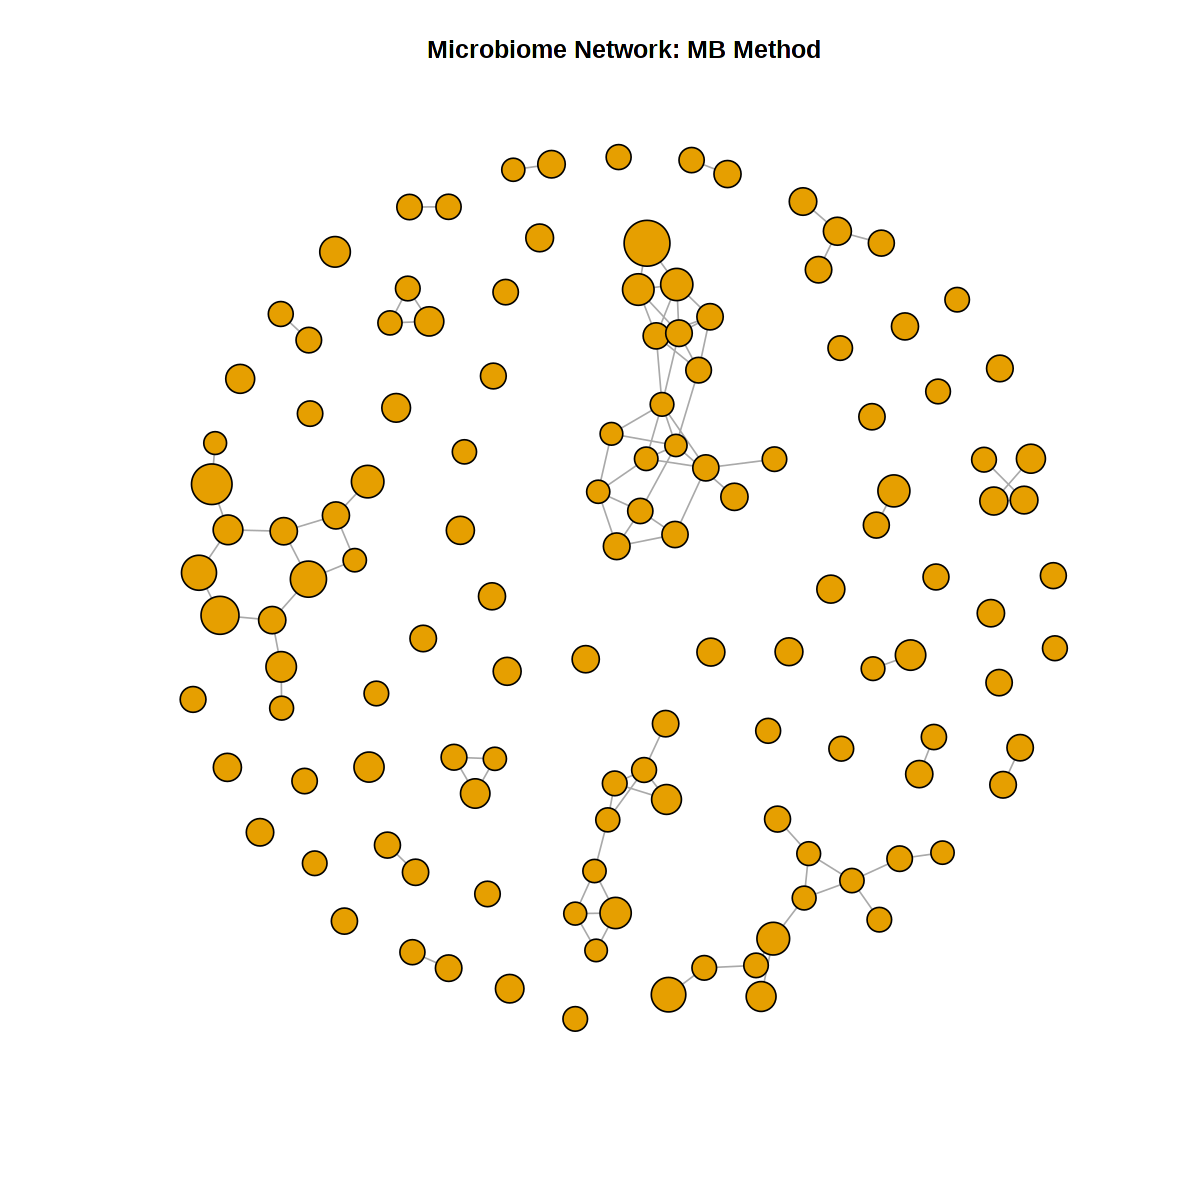

In [ ]:
class(se.out)
ig.mb     <-  adj2igraph(getRefit(se.out))
## set size of vertex proportional to clr-mean
vsize    <- rowMeans(clr(amgut1.filt, 1))+6
am.coord <- igraph::layout_with_fr(ig.mb)
options(repr.plot.width = 10, repr.plot.height = 10)
par(mfrow=c(1,1))

# plot using igraph
plot(ig.mb,
     layout = am.coord,
     vertex.size = vsize,
     vertex.label = NA,
     main = "Microbiome Network: MB Method")



---
**Installing heavy GitHub packages**

OK, now the heavy part, which is installing NetCoMi (its dependencies first)
from GitHub, again if needed. I am splitting this in multiple blocks to isolate the problems. **Note that 5.3 can take forever (almost...)**

In [ ]:
# --- PART 5.1: mixedCCA install ---

check_github_package(.github_packages[["mixedCCA"]], "mixedCCA")



──────────────────────────────────────────────────
⏳  WORKING: Checking: mixedCCA
──────────────────────────────────────────────────



>>> [SKIP] mixedCCA already present in restored library.




──────────────────────────────────────────────────
✅  SUCCESS: mixedCCA loaded from restored library.
──────────────────────────────────────────────────



In [ ]:
# --- PART 5.2: SPRING install ---


check_github_package(.github_packages[["SPRING"]], "SPRING")



──────────────────────────────────────────────────
⏳  WORKING: Checking: SPRING
──────────────────────────────────────────────────



>>> [SKIP] SPRING already present in restored library.




──────────────────────────────────────────────────
✅  SUCCESS: SPRING loaded from restored library.
──────────────────────────────────────────────────



In [ ]:
# --- PART 5.3: The Clean Approach to NetCoMi install ---

check_github_package(.github_packages[["NetCoMi"]], "NetCoMi")



──────────────────────────────────────────────────
⏳  WORKING: Checking: NetCoMi
──────────────────────────────────────────────────



>>> [SKIP] NetCoMi already present in restored library.




──────────────────────────────────────────────────
✅  SUCCESS: NetCoMi loaded from restored library.
──────────────────────────────────────────────────



---
## **Testing NetCoMi for network inference and analysis**

We are finally there: I am now testing NetCoMi with code from https://netcomi.de/articles/netcomi

Column 7 contains NAs only and is ignored.



,Rank1,Rank2,Rank3,Rank4,Rank5,Rank6,Rank7
181016,k__Bacteria,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Ruminococcaceae,g__Eubacterium,NA
189396,k__Bacteria,p__Firmicutes,c__Clostridia,o__Clostridiales,f__Lachnospiraceae,g__Eubacterium,NA


Checking input arguments ... 
Done.

Data filtering ...

35 samples removed.

43 taxa and 261 samples remaining.


Calculate 'spring' associations ... 
Done.



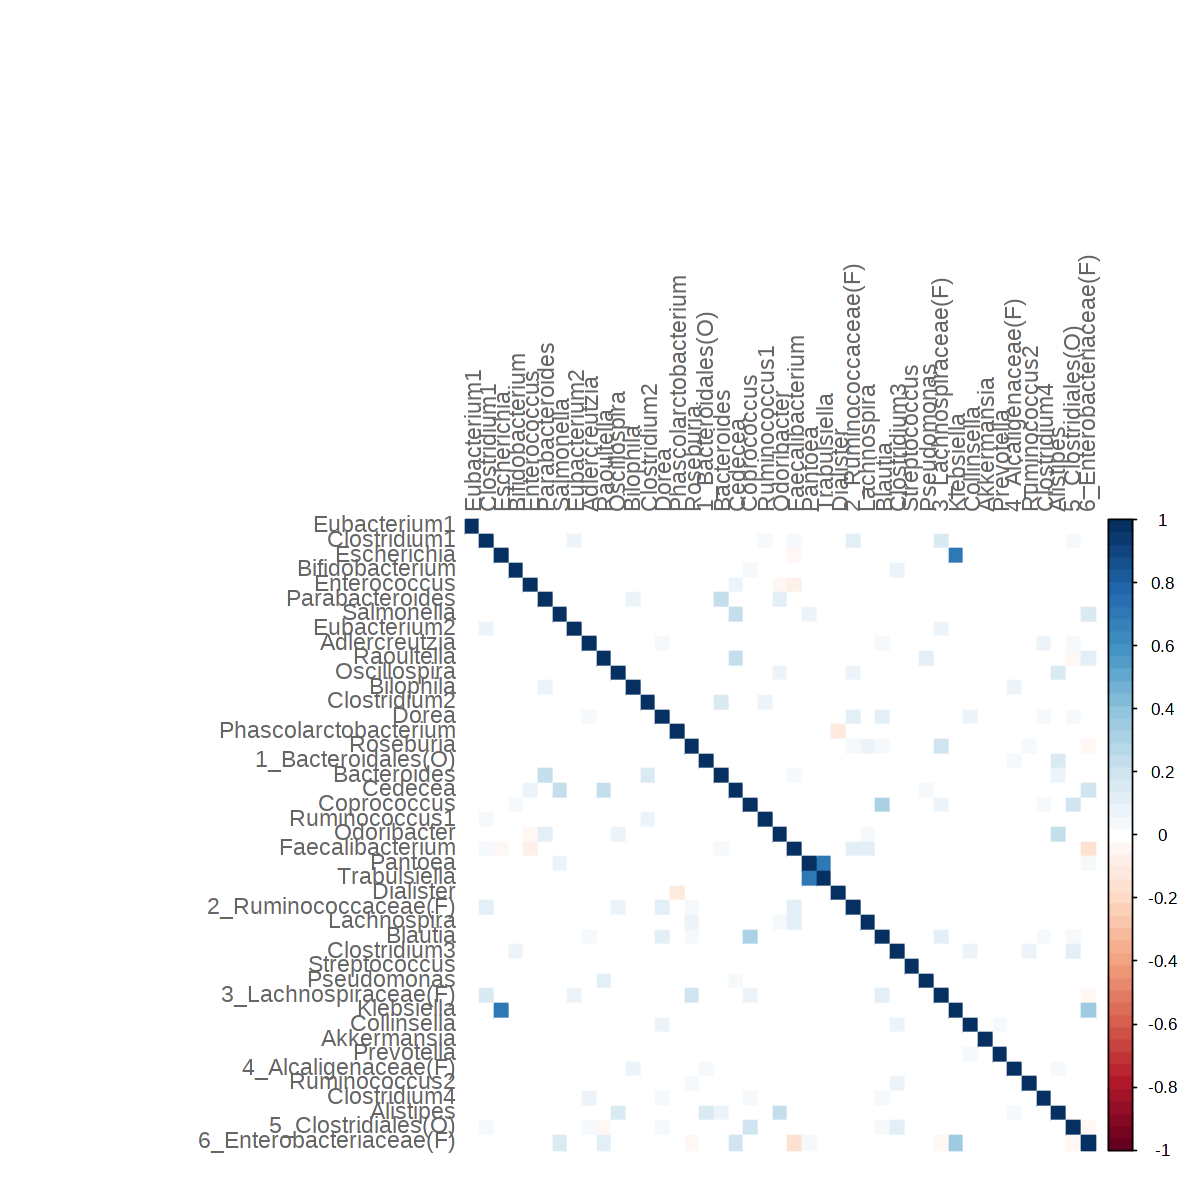


Component sizes
```````````````            
size: 40 2 1
   #:  1 1 1
______________________________
Global network properties
`````````````````````````
Largest connected component (LCC):
                                 
Relative LCC size         0.93023
Clustering coefficient    0.30444
Modularity                0.44962
Positive edge percentage 83.65385
Edge density              0.13333
Natural connectivity      0.03658
Vertex connectivity       1.00000
Edge connectivity         1.00000
Average dissimilarity*    0.95727
Average path length**     1.84697

Whole network:
                                 
Number of components      3.00000
Clustering coefficient    0.30444
Modularity                0.45572
Positive edge percentage 82.85714
Edge density              0.11628
Natural connectivity      0.03337
-----
*: Dissimilarity = 1 - edge weight
**: Path length = Units with average dissimilarity

______________________________
Clusters
- In the whole network
- Algorithm: cluster_fast_g

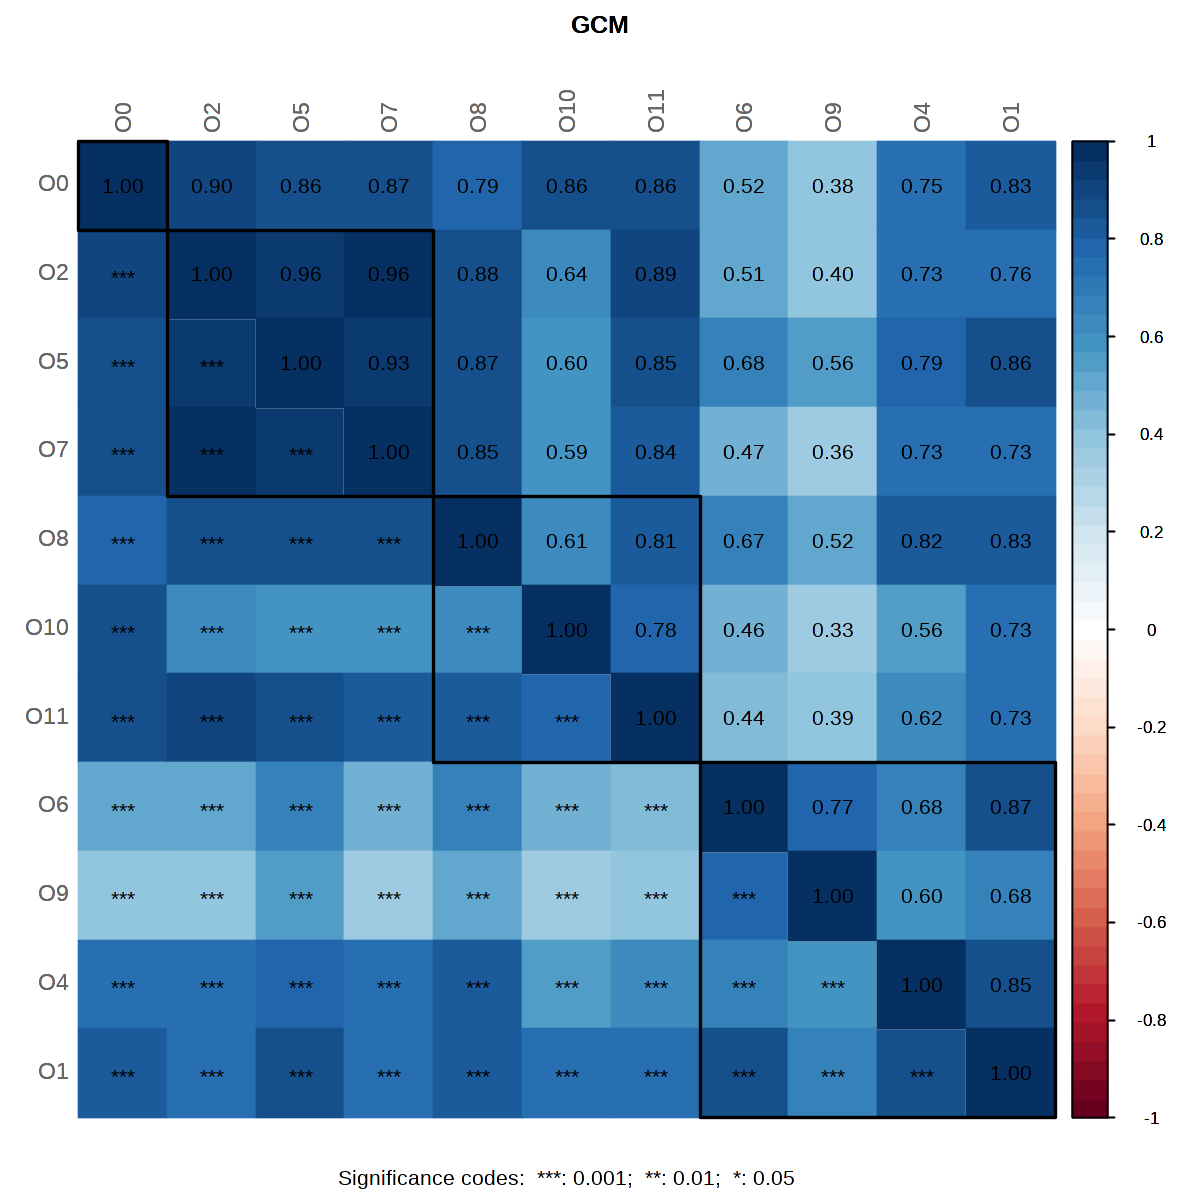

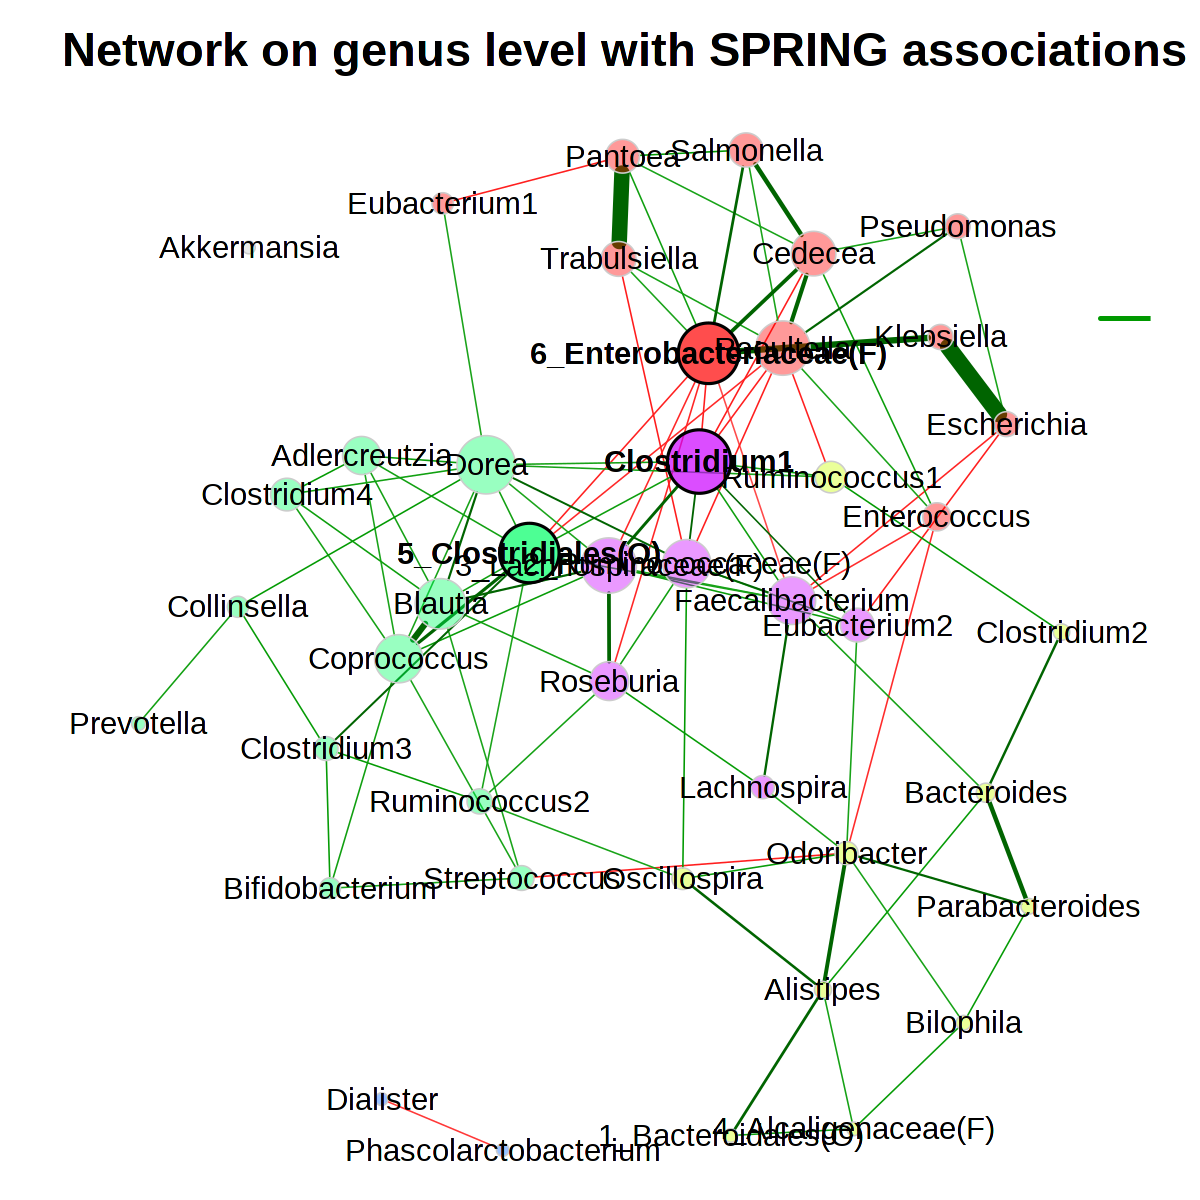

In [ ]:
# --- PART 6: Test NetCoMi ---

require(NetCoMi)
require(phyloseq)

# Load data sets
data("amgut1.filt") # ASV count matrix
data("amgut2.filt.phy") # phyloseq objext

# Agglomerate to genus level
amgut_genus <- tax_glom(amgut2.filt.phy, taxrank = "Rank6")

# Rename taxonomic table and make Rank6 (genus) unique
amgut_genus_renamed <- renameTaxa(amgut_genus,
                                  pat = "<name>",
                                  substPat = "<name>_<subst_name>(<subst_R>)",
                                  numDupli = "Rank6")
taxtab <- tax_table(amgut_genus)
taxtab[taxtab[, "Rank6"] == "g__Eubacterium", ]

# build a network with Spring
net_spring <- netConstruct(amgut_genus_renamed,
                           taxRank = "Rank6",
                           filtTax = "highestFreq",
                           filtTaxPar = list(highestFreq = 50),
                           filtSamp = "totalReads",
                           filtSampPar = list(totalReads = 1000),
                           measure = "spring",
                           measurePar = list(nlambda=10,
                                             rep.num=10,
                                             Rmethod = "approx"),
                           normMethod = "none",
                           zeroMethod = "none",
                           sparsMethod = "none",
                           dissFunc = "signed",
                           verbose = 2,
                           seed = 123456)

# look at associations as heat map
plotHeat(net_spring$assoMat1, textUpp = "none", textLow = "none")

# perform network analysis with defaults
props_spring <- netAnalyze(net_spring,
                           centrLCC = TRUE,
                           clustMethod = "cluster_fast_greedy",
                           hubPar = "eigenvector",
                           weightDeg = FALSE,
                           normDeg = FALSE)
# get summary

#?summary.microNetProps
summary(props_spring, numbNodes = 5L)

# plot the network using NetCoMi
p <- plot(props_spring,
          labelScale = FALSE,
          nodeColor = "cluster",
          nodeSize = "eigenvector",
          title1 = "Network on genus level with SPRING associations",
          showTitle = TRUE,
          cexTitle = 2.3,
          cexLabels = 1.5)

legend(0.7, 1.1, cex = 2.2, title = "estimated association:",
       legend = c("+","-"), lty = 1, lwd = 3, col = c("#009900","red"),
       bty = "n", horiz = TRUE)


## **Saving the library**.
Installing and loading the packages was exhausting. I will now conditionally save the library to my drive to make the use of the notebook faster next time it is opened. **Note**: I have left a back door to reset needs_backup, just set `reset_needs_backup to <-T`.

In [ ]:
# --- PART 7: Robust Sync to Drive ---

# Force a backup regardless of needs_backup by setting this to TRUE
reset_needs_backup <- FALSE
if (reset_needs_backup) needs_backup <- TRUE

if (exists("needs_backup")) {
  cat("\nneeds_backup flag is", needs_backup, "\n")
} else {
  colab_msg("needs_backup not defined — skipping backup.", "info")
}

if (install_on_drive && exists("needs_backup") && needs_backup) {

  colab_msg("Compressing library — this may take a moment...", "working")
  old_wd <- getwd()
  setwd("/content")
  system("zip -r lib_backup.zip R_library_local")

  if (file.exists("lib_backup.zip")) {

    colab_msg("Uploading library to Google Drive.\nDo not close this tab.", "working")

    # Server-side exact name match (consistent with Part 1)
    .drive_file <- drive_find(
      q     = paste0("name = '", drive_zip_path, "'"),
      n_max = 1
    )

    if (nrow(.drive_file) > 0) {
      googledrive::drive_update(.drive_file, "lib_backup.zip")
      colab_msg("Google Drive backup updated successfully.", "success")
    } else {
      googledrive::drive_upload("lib_backup.zip", name = drive_zip_path)
      colab_msg("New Google Drive backup created successfully.", "success")
    }

    file.remove("lib_backup.zip")

  } else {
    colab_msg("Zip file was not created — check available disk space.", "warning")
    stop("Aborting: backup zip not found.")
  }

  needs_backup <- FALSE
  setwd(old_wd)

} else {
  colab_msg("No changes detected — Google Drive backup not needed.", "info")
}


needs_backup flag is FALSE 

──────────────────────────────────────────────────
ℹ️  INFO: No changes detected — Google Drive backup not needed.
──────────────────────────────────────────────────



# Miscellaneous.  

## Does it work?   

I have tested this using

*   Google Chrome Version 148.0.7778.180 (Official build) (arm64)

*   Brave browser Release Notes v1.90.124 (May 20, 2026) (arm64)

*   Safari 26.5 (21624.2.5.11.4)

and, as far I can see it works



## Version.  
This is version 2, 24/05/2026


## Credits.  
Most of the code for the creation and restoring of libraries from Google Drive and for installing GitHub packages in a CoLab notebook was produced by Google Gemini AI with my prompts.  Some inconsistencies were then fixed with Claude Sonnet 4.6

MIT License


## Copyright.  
Copyright (c) [2026] [Eugenio Parente]

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.